# Linear Regression with Scikit Learn

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [81]:
# 1. Generate data

X_train = 2 * np.random.rand(100,1) * 10 + 5
y_train = (1.5 * X_train + 2 + np.random.rand(100, 1) * 1.5).flatten()

In [82]:
print(f"X_train sample {X_train[:10]}")
print(f"y_train sample {y_train[:10]}")

X_train sample [[17.43700471]
 [19.75323035]
 [ 7.69089464]
 [13.83555802]
 [15.94774005]
 [21.34225749]
 [ 7.85174409]
 [17.0224026 ]
 [24.47621706]
 [12.39725342]]
y_train sample [28.62579429 32.8426826  13.55759929 23.34853018 26.82687838 34.32589611
 14.5795487  28.91154884 38.82154456 22.03751659]


In [83]:
#2. instantiate the model
model = LinearRegression()

# 3. Fit the model to the training data - to learn the weights and biases
model.fit(X_train, y_train)

print(f"X_train sample {X_train[:10]}")
print(f"y_train sample {y_train[:10]}")






X_train sample [[17.43700471]
 [19.75323035]
 [ 7.69089464]
 [13.83555802]
 [15.94774005]
 [21.34225749]
 [ 7.85174409]
 [17.0224026 ]
 [24.47621706]
 [12.39725342]]
y_train sample [28.62579429 32.8426826  13.55759929 23.34853018 26.82687838 34.32589611
 14.5795487  28.91154884 38.82154456 22.03751659]


In [84]:
# 4. Print the learned coefficients

#sklearn stores the learned coefficients in 'coef_' and the bias in 'intercept'

print(f"Learned Cofficients (weights) {model.coef_[0]:.2f}")
print(f"Learned intercet (Bias): {model.intercept_:.4f}")



Learned Cofficients (weights) 1.51
Learned intercet (Bias): 2.6457


In [85]:
# 5. Make the predictions

y_predicted = model.predict(X_train)



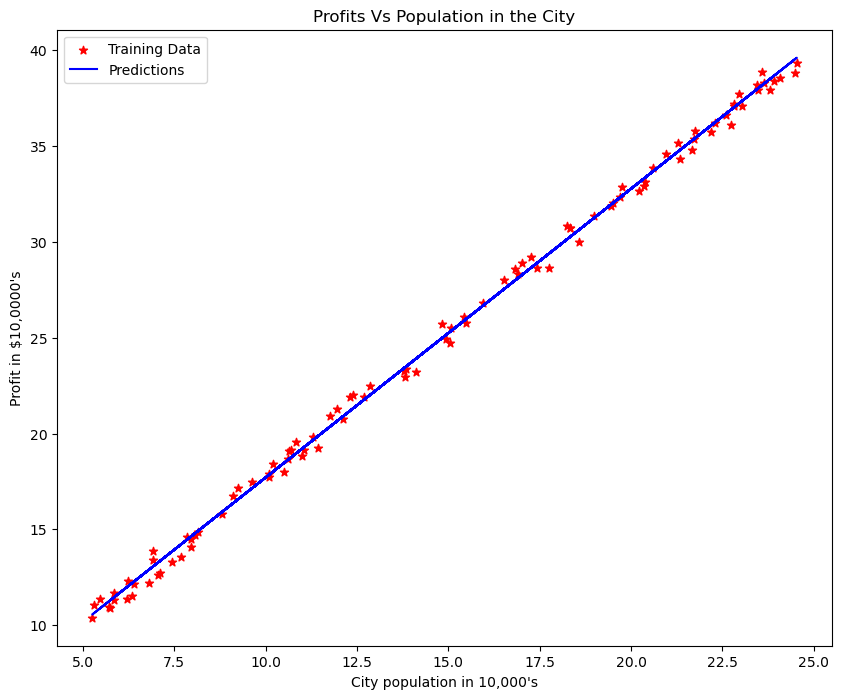

In [86]:
plt.figure(figsize=(10,8))
plt.scatter(X_train, y_train, marker='*', c='r', label='Training Data')
plt.plot(X_train, y_predicted, c='b', label='Predictions')

plt.title("Profits Vs Population in the City")
plt.ylabel('Profit in $10,0000\'s')
plt.xlabel('City population in 10,000\'s')
plt.legend()
plt.grid(0)
plt.show()


## Evaluation

 1. Mean Squared Error (MSE): It measures the average of the squared differences between the predicted and actual values. Lower is better.
 2. RMSE (Root Mean Squre error) is square root of MSE. Lower the better, same units as the predicted variable

 3. Coefficient of Determination (R2 Score): More intutive measure of how well the model explains the variance in the data. An R2 of 1 means the model perfectly predicts the target variable, while r2 = 0 means the model just performs prediction of the mean the data.

 The R-squared (R²) score, also known as the coefficient of determination, is a statistical measure that represents the proportion of variance in the dependent variable that can be explained by the independent variables in a regression model. It essentially indicates how well the model fits the data, with higher values suggesting a better fit. 

 A higher R-squared suggests that the model's predictions are closer to the observed values.
 
Not a measure of causation:
While R-squared indicates how well the model fits, it doesn't imply causation between the variables. A high R-squared could be due to a strong correlation, but not necessarily a causal relationship. 

Limitations:
R-squared can be misleading if used in isolation. A high R-squared doesn't guarantee that the model is unbiased or that the predictions are accurate. It's essential to consider other factors like residual plots and statistical significance of the coefficients. 

In essence, R-squared helps assess how well a regression model captures the variability in the data and provides a useful metric for comparing the performance of different models. 





 

In [113]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_train, y_predicted)
rmse = np.sqrt(mse)

r2 = r2_score(y_train, y_predicted)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Coefficient of Determination (R^2): {r2:.4f}")

Mean Squared Error (MSE): 0.1823
Root Mean Squared Error (RMSE): 0.4270
Coefficient of Determination (R^2): 0.9979


## Improving the Model: Addressing Bias and Variance

When a model doesn't perform well, it's often due to one of two problems: high bias or high variance.

**Bias**: This refers to the model's simplifying assumptions, which can cause it to miss the true relationship in the data. A simple linear model applied to a non-linear problem would have high bias. This is an underfitting problem.

Solution: Use a more complex model (e.g., a polynomial regression or a Decision Tree), add more relevant features, or reduce regularization.

**Variance**: This refers to the model's sensitivity to small fluctuations in the training data. A model with high variance performs well on the training data but poorly on unseen data. This is an overfitting problem.

Solution: Use a simpler model, get more training data, or apply regularization.

**C. Regularization**
Regularization is a key technique to combat overfitting by adding a penalty to the cost function for large coefficients. This forces the model to use smaller, more stable weights.

L1 Regularization (Lasso): Adds a penalty proportional to the absolute value of the coefficients. It can force some coefficients to become exactly zero, effectively performing feature selection.

L2 Regularization (Ridge): Adds a penalty proportional to the square of the coefficients. It shrinks the coefficients but doesn't force them to zero.

